Using device: cuda


100%|██████████| 170M/170M [51:17<00:00, 55.4kB/s]



🔹 Training VGG on CIFAR-10...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 97.3MB/s]


VGG Epoch 1/5 - Train Acc: 26.50%, Val Acc: 64.00%
VGG Epoch 2/5 - Train Acc: 62.00%, Val Acc: 69.00%
VGG Epoch 3/5 - Train Acc: 80.75%, Val Acc: 71.00%
VGG Epoch 4/5 - Train Acc: 92.75%, Val Acc: 71.00%
VGG Epoch 5/5 - Train Acc: 92.25%, Val Acc: 67.00%

🔹 Training RESNET on CIFAR-10...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


RESNET Epoch 1/5 - Train Acc: 27.25%, Val Acc: 53.00%
RESNET Epoch 2/5 - Train Acc: 91.50%, Val Acc: 63.00%
RESNET Epoch 3/5 - Train Acc: 99.75%, Val Acc: 74.00%
RESNET Epoch 4/5 - Train Acc: 100.00%, Val Acc: 75.00%
RESNET Epoch 5/5 - Train Acc: 100.00%, Val Acc: 74.00%

🔹 Training GOOGLENET on CIFAR-10...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 187MB/s]


GOOGLENET Epoch 1/5 - Train Acc: 26.75%, Val Acc: 38.00%
GOOGLENET Epoch 2/5 - Train Acc: 72.75%, Val Acc: 58.00%
GOOGLENET Epoch 3/5 - Train Acc: 85.00%, Val Acc: 65.00%
GOOGLENET Epoch 4/5 - Train Acc: 94.75%, Val Acc: 72.00%
GOOGLENET Epoch 5/5 - Train Acc: 96.50%, Val Acc: 73.00%


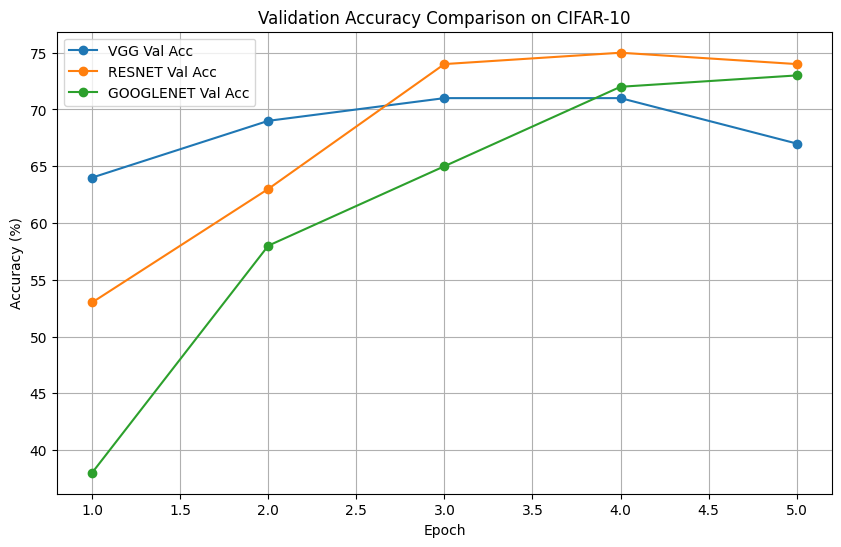


❗ Image not found: download.jpeg. Please add an image to test.


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split, Subset

# ---------- Setup ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset = Subset(dataset, range(500))   # small subset for speed
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ---------- Training function ----------
def train_and_evaluate(model, name, num_epochs=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_accs.append(100 * correct / total)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_accs.append(100 * correct / total)

        print(f"{name} Epoch {epoch+1}/{num_epochs} - "
              f"Train Acc: {train_accs[-1]:.2f}%, Val Acc: {val_accs[-1]:.2f}%")

    return model, train_accs, val_accs

# ---------- Model factory ----------
def get_model(name):
    if name == "vgg":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(4096, 10)
    elif name == "resnet":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 10)
    elif name == "googlenet":
        model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        model.aux_logits = False      # forward returns only the main output
        model.aux1 = None
        model.aux2 = None
        model.fc = nn.Linear(model.fc.in_features, 10)
    else:
        raise ValueError("Unknown model")
    return model

# ---------- Train all models ----------
results, trained_models = {}, {}

for name in ["vgg", "resnet", "googlenet"]:
    print(f"\n🔹 Training {name.upper()} on CIFAR-10...")
    net = get_model(name)
    trained, train_acc, val_acc = train_and_evaluate(net, name.upper(), num_epochs=5)
    results[name] = (train_acc, val_acc)
    trained_models[name] = trained

# ---------- Plot validation accuracy ----------
plt.figure(figsize=(10, 6))
for name, (train_acc, val_acc) in results.items():
    plt.plot(range(1, len(val_acc) + 1), val_acc, marker='o', label=f'{name.upper()} Val Acc')
plt.title('Validation Accuracy Comparison on CIFAR-10')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# ---------- Predict on a custom image ----------
def predict_image(image_path, models_dict):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    print(f"\n🖼 Prediction results for image: {image_path}")
    for model_name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            pred = model(image).argmax(1).item()
        print(f"{model_name.upper():<10} => {class_names[pred]}")

custom_image_path = "download.jpeg"
if os.path.exists(custom_image_path):
    predict_image(custom_image_path, trained_models)
else:
    print(f"\n❗ Image not found: {custom_image_path}. Please add an image to test.")